In [ ]:
#Name : Gulame Vishal Yashavant 
#Div: A 
#Roll No: 57

In [1]:
!jupyter nbconvert --to webpdf "Deep learning lab 10.ipynb"

[NbConvertApp] Converting notebook Deep learning lab 10.ipynb to webpdf
,[NbConvertApp] WARNING | Alternative text is missing on 1 image(s).
,[NbConvertApp] Building PDF
,[NbConvertApp] PDF successfully created
,[NbConvertApp] Writing 143984 bytes to Deep learning lab 10.pdf


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Flatten, Reshape
from tensorflow.keras.optimizers import Adam

In [2]:
(x_train, _), (x_test, _) = fashion_mnist.load_data()

In [3]:
x_train = x_train / 255.0
x_test = x_test / 255.0

In [4]:
x_train = x_train.reshape(len(x_train), 784)
x_test = x_test.reshape(len(x_test), 784)

In [6]:
print("Training Data Shape:", x_train.shape)
print("Testing Data Shape:", x_test.shape)

Training Data Shape: (60000, 784)
,Testing Data Shape: (10000, 784)


In [7]:
input_layer = Input(shape=(784,))

# Encoder
encoder = Dense(128, activation='relu')(input_layer)
encoder = Dense(64, activation='relu')(encoder)
latent = Dense(32, activation='relu')(encoder)

In [8]:
# Decoder
decoder = Dense(64, activation='relu')(latent)
decoder = Dense(128, activation='relu')(decoder)
output_layer = Dense(784, activation='sigmoid')(decoder)

In [9]:
autoencoder = Model(inputs=input_layer, outputs=output_layer)

In [10]:
autoencoder.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['accuracy']
)

In [11]:
history = autoencoder.fit(
    x_train, x_train,
    epochs=20,
    batch_size=256,
    validation_data=(x_test, x_test)
)

Epoch 1/20
,235/235 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.0076 - loss: 0.0468 - val_accuracy: 0.0139 - val_loss: 0.0250
,Epoch 2/20
,235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.0138 - loss: 0.0231 - val_accuracy: 0.0152 - val_loss: 0.0213
,Epoch 3/20
,235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.0147 - loss: 0.0200 - val_accuracy: 0.0145 - val_loss: 0.0194
,Epoch 4/20
,235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.0161 - loss: 0.0184 - val_accuracy: 0.0176 - val_loss: 0.0177
,Epoch 5/20
,235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.0161 - loss: 0.0172 - val_accuracy: 0.0180 - val_loss: 0.0169
,Epoch 6/20
,235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.0174 - loss: 0.0163 - val_accuracy: 0.0168 - val_loss: 0.0160
,Epoch 7/20
,235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.0162 - loss: 0.0157 - val_accuracy: 0.0185 - val_loss: 0.0154
,Epoch 8/20
,235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.0180 - loss: 0

In [12]:
reconstructed = autoencoder.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


In [13]:
reconstruction_error = np.mean(np.square(x_test - reconstructed), axis=1)

In [14]:
threshold = np.mean(reconstruction_error) + 2 * np.std(reconstruction_error)
print("Threshold:", threshold)

Threshold: 0.02887252437829347


In [15]:
anomalies = reconstruction_error > threshold
print("Number of Anomalies Detected:", np.sum(anomalies))

Number of Anomalies Detected: 451


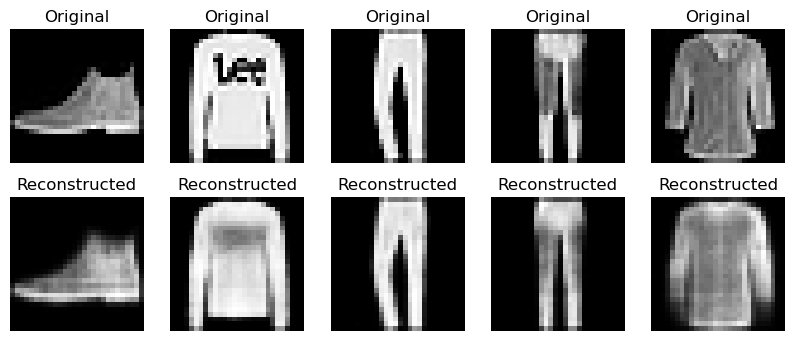

In [16]:
plt.figure(figsize=(10, 4))

for i in range(5):
    # Original
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Reconstructed
    plt.subplot(2, 5, i + 6)
    plt.imshow(reconstructed[i].reshape(28, 28), cmap='gray')
    plt.title("Reconstructed")
    plt.axis('off')

plt.show()